In [1]:
from common_setup import *


In [2]:
colors

['#A7216A', '#802000', '#E24912']

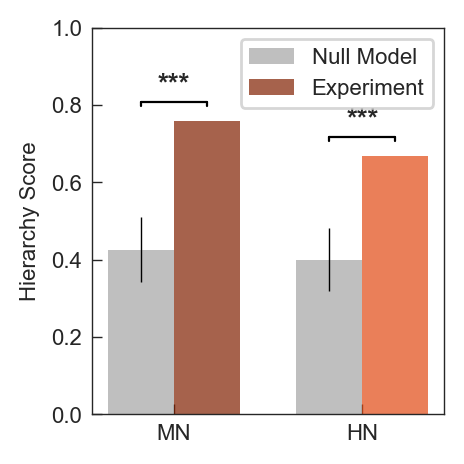

In [5]:
from scipy.stats import norm
import matplotlib.pyplot as plt
import numpy as np

def plot_hierarchy_score_comparison(actual_scores, null_means, null_stds, colors):
    """
    Plot bar chart of hierarchy scores for MN and HN with null expectation and significance stars.
    
    Returns:
        fig: matplotlib figure object
    """
    from scipy.stats import norm
    mm = 1 / 25.4
    conditions = ['MN', 'HN']
    
    # Z-test for significance
    z_scores = [(a - m) / s for a, m, s in zip(actual_scores, null_means, null_stds)]
    p_values = [1 - norm.cdf(z) for z in z_scores]  # one-sided test (actual > null)

    # Plot setup
    x = np.arange(len(conditions))
    bar_width = 0.35
    fig, ax = plt.subplots(figsize=(60 * mm, 60 * mm))

    # Null model bars (gray)
    ax.bar(x - bar_width/2, null_means, bar_width, yerr=null_stds, capsize=0, alpha=0.5,
           edgecolor='none', error_kw={'elinewidth': .5, 'capthick': 0}, label='Null Model', color='grey')

    # Real data bars (color-coded)
    ax.bar(x + bar_width/2, actual_scores, bar_width, capsize=0, alpha=0.7, edgecolor='none',
           error_kw={'elinewidth': .5, 'capthick': 0}, label='Experiment', color=[colors[1], colors[2]])

    # Axis settings
    ax.set_xticks(x)
    ax.set_xticklabels(conditions)
    ax.set_ylim(0, 1)
    ax.set_ylabel("Hierarchy Score")
    ax.legend()

    # Significance stars
    def p_to_stars(p):
        if p < 0.001:
            return '***'
        elif p < 0.01:
            return '**'
        elif p < 0.05:
            return '*'
        else:
            return 'n.s.'

    for i, p in enumerate(p_values):
        stars = p_to_stars(p)
        y1 = null_means[i] + null_stds[i]
        y2 = actual_scores[i]
        y = max(y1, y2) + 0.05

        # Bracket
        ax.plot([x[i] - bar_width/2, x[i] + bar_width/2], [y, y], color='black', linewidth=0.8)
        ax.plot([x[i] - bar_width/2, x[i] - bar_width/2], [y - 0.01, y], color='black', linewidth=0.8)
        ax.plot([x[i] + bar_width/2, x[i] + bar_width/2], [y - 0.01, y], color='black', linewidth=0.8)

        # Stars
        ax.text(x[i], y + 0.01, stars, ha='center', va='bottom', fontsize=10, fontweight='bold')

    plt.tight_layout()
    return fig

actual_scores = [0.758, 0.667]
null_means = [0.425, 0.400]
null_stds = [0.084, 0.082]

# Your color palette, e.g.:

fig = plot_hierarchy_score_comparison(actual_scores, null_means, null_stds, colors)
fig.savefig("/Users/jysong/Desktop/Gore_lab/Sequencing/Coalescence_session_20230404/Figure_generate/code/Figure/hierarchy_score_comparison.svg", format='svg')


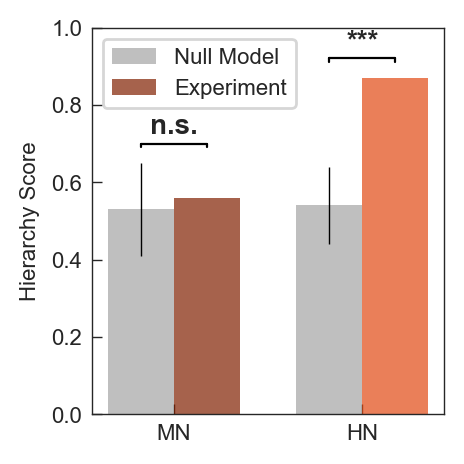

In [16]:

actual_scores = [0.558, 0.87]
null_means = [0.53, 0.54]
null_stds = [0.12, 0.10]

# Your color palette, e.g.:

fig = plot_hierarchy_score_comparison(actual_scores, null_means, null_stds, colors)
fig.savefig("/Users/jysong/Desktop/Gore_lab/Sequencing/Coalescence_session_20230404/Figure_generate/code/Figure/hierarchy_score_comparison_community.svg", format='svg')


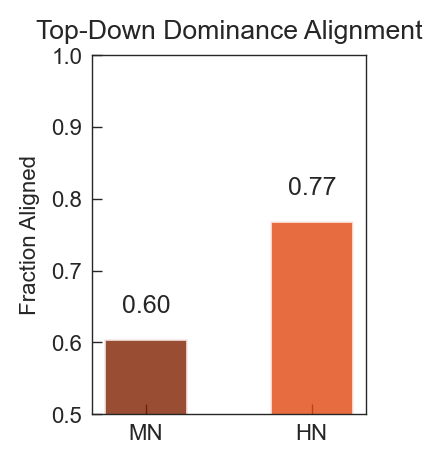

In [21]:
def plot_alignment_fraction_bar(fractions, colors):
    """
    Plot alignment fractions for MN and HN (no null model).
    
    Args:
        fractions: list of alignment fractions [MN, HN]
        colors: list of colors where MN uses colors[1], HN uses colors[2]
    
    Returns:
        fig: matplotlib figure object
    """
    import matplotlib.pyplot as plt
    import numpy as np

    mm = 1 / 25.4
    x = np.arange(2)
    labels = ['MN', 'HN']
    
    fig, ax = plt.subplots(figsize=(50 * mm, 60 * mm))
    bar_width = 0.5

    ax.bar(x, fractions, bar_width, color=[colors[1], colors[2]], alpha=0.8)

    # Annotate values on top
    for i, val in enumerate(fractions):
        ax.text(x[i], val + 0.03, f"{val:.2f}", ha='center', va='bottom', fontsize=9)

    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylim(0.5, 1)
    ax.set_ylabel("Fraction Aligned")
    ax.set_title("Top-Down Dominance Alignment")

    plt.tight_layout()
    return fig
fractions = [0.605, 0.769]  # MN and HN

fig = plot_alignment_fraction_bar(fractions, colors)
fig.savefig("/Users/jysong/Desktop/Gore_lab/Sequencing/Coalescence_session_20230404/Figure_generate/code/Figure/alignment_fraction_comparison.svg", format='svg')
